In [ ]:
https://www.kaggle.com/learn/pandas

In [2]:
import pandas as pd
import numpy as np
import statistics as st
import re
import matplotlib.pyplot as plt
#pip install mysql-connector-python pandas scikit-learn
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [10]:
# pip install pandas jupyter matplotlib

### Pyhthon TIPS

In [ ]:
1. The Quickest Way: ? (Jupyter Exclusive)
Since you are using Jupyter, you can simply put a question mark before or after any function and hit Shift + Enter.

Python
pd.read_csv?
Result: A window pops up at the bottom of the screen showing you all the parameters (like encoding, sep, header) and a description of what they do.
# EXAMPLES
df1.join?
df1.join?? # fOR Python to actually show you the source code of the function so you can see exactly how it’s built.*

2. The Universal Way: help()
This works in any Python console (PyCharm, Jupyter, or Terminal). It prints the full documentation directly into your output.

Python
# EXAMPLE ONE
help(pd.read_excel)
Pro Tip: This is great for checking which "parts" (parameters) a function accepts—for example, it would have shown you that read_excel does not have an encoding parameter.

# EXAMPLE TWO
df1 = pd.DataFrame()
# This prints the official manual for the join method
help(df1.join)    
    
3. The "Skeleton" View: dir()
If you want to see all the hidden "parts" or sub-methods attached to a function or object, use dir().

Python
import pandas as pd
print(dir(pd))
# Result: This returns a huge list of every "part" inside the Pandas library. If you use it on your DataFrame (dir(df)), it will show you every single thing you can do to that data (like .mean(), .sum(), .loc(), etc.).

4. The "Signature" Trick: Shift + Tab
This is the "Developer's Favorite" in Jupyter.

Type pd.read_csv(

Hold Shift and tap Tab.

Result: A small tooltip appears instantly showing the "Signature" (the list of arguments). Tap Tab a second time to expand it into the full manual.

5. The __doc__ Attribute
If you want to print just the raw text of the documentation without the "help" interface:
# EXAMPLE:
print(df1.join.__doc__)

### 'Standard' Sections of Data Analysis

In [ ]:
# Full-scale analysis ORDER:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Using the Raw string (r'') and the encoding fix you discovered
df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\artists.csv', encoding='cp1252')

# 2. INSPECT (The "Investigation")
print("--- Column Headers Found ---")
print(df.columns)
print("\n--- Data Summary ---")
print(df.info())

# 3. CLEAN (The "Safety Net" or Filling in data, dropping rows, removing duplicates)
# Let's clean the dates. 'coerce' turns non-numbers (like "unknown") into NaN (Not a Number)
df['BeginDate'] = pd.to_numeric(df['BeginDate'], errors='coerce')
df['EndDate'] = pd.to_numeric(df['EndDate'], errors='coerce')

# Fill missing dates with 0 so the math doesn't break, or leave as NaN
df = df.dropna(subset=['BeginDate', 'EndDate']) # Optional: removes artists with missing dates

# Create a new column: Age at death
df['Lifespan'] = df['EndDate'] - df['BeginDate']

# 4. SUMMARISE (NumPy Stats)
# Let's find the average lifespan of the artists in this list
lifespan_array = df['Lifespan'].values
print(f"\nAverage Artist Lifespan: {np.mean(lifespan_array):.1f} years")
print(f"Oldest Artist in data: {np.max(lifespan_array):.0f} years")

# 5. VISUALISE
plt.figure(figsize=(10, 6))
df['Lifespan'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Artist Lifespans')
plt.xlabel('Age at Death')
plt.ylabel('Number of Artists')
plt.savefig('artist_lifespan_hist.png')

# 6. EXPORT
df.to_csv(r'C:\Users\micha\OneDrive\Desktop\cleaned_artists.csv', index=False)
print("\nSuccess! Your cleaned data is saved as 'cleaned_artists.csv'")numpy as np
import matplotlib.pyplot as plt

### Creating, Reading and Writing

In [3]:
# Creating DataFrame:

df_cr = pd.DataFrame({'ConstituentID': [11],
'DisplayName':['Jean (Hans) Arp	French'],
'ArtistBio':['born Germany (Alsace). 1886–1966'],	
'Nationality':['French'],
'Gender':['Male'],
'BeginDate':['28/02/1905'],
'EndDate':['19/05/1905']
    })

df_cr

,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate
0,11,Jean (Hans) Arp\tFrench,born Germany (Alsace). 1886–1966,French,Male,28/02/1905,19/05/1905


In [ ]:
# Adding values to the created DafaFrame:



In [1]:
import pandas as pd

In [6]:
# Importing DataFrame as:
df = pd.read_csv('C:\\Users\\micha\\OneDrive\\Desktop\\artists.csv', encoding='cp1252')
df.head()
# df.tail()


,ConstituentID,DisplayName,ArtistBio,Nationality,Gender,BeginDate,EndDate
0,11,Jean (Hans) Arp,"French, born Germany (Alsace). 1886–1966",French,male,28/02/1905,19/05/1905
1,19,Richard Artschwager,"American, 1923–2013",American,male,06/04/1905,05/07/1905
2,34,Alvar Aalto,"Finnish, 1898–1976",Finnish,male,12/03/1905,29/05/1905
3,38,Magdalena Abakanowicz,"Polish, 1930–2017",Polish,female,13/04/1905,09/07/1905
4,60,Ansel Adams,"American, 1902–1984",American,male,16/03/1905,06/06/1905


In [68]:
# DataFrame General Information:

#print(df.info()) # For more detaild columns & overall info (but cannot be added in a variable)
#print(df.describe()) # For stats of numerical values only like mean, count, min, max etc..
#df.shape # For the number of rows and columns
#len(df), len(df.columns) # Same as above
#df.columns.size # For number of columns only
#df.dtypes # For how the data is stored 
#df.dtypes.value_counts() # For str, int info


#print(df.describe()) # For stats of numerical values only like mean, count, min, max etc..
# This shows stats for both the Numbers AND the Text or Object columns
#df.describe(include='all')

# Or preferrably just the Text columns specifically (Capital 'O' for Object)
#df.describe(include='O')
#Tutorial Video at: https://www.youtube.com/watch?v=BspcRHPiFk4

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATA
# Using the Raw string (r'') and the encoding fix you discovered
df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\artists.csv', encoding='cp1252')

# 2. INSPECT (The "Investigation")
print("--- Column Headers Found ---")
print(df.columns)
print("\n--- Data Summary ---")
print(df.info())

# 3. CLEAN (The "Safety Net")
# Let's clean the dates. 'coerce' turns non-numbers (like "unknown") into NaN (Not a Number)
df['BeginDate'] = pd.to_numeric(df['BeginDate'], errors='coerce')
df['EndDate'] = pd.to_numeric(df['EndDate'], errors='coerce')

# Fill missing dates with 0 so the math doesn't break, or leave as NaN
df = df.dropna(subset=['BeginDate', 'EndDate']) # Optional: removes artists with missing dates

# Create a new column: Age at death
df['Lifespan'] = df['EndDate'] - df['BeginDate']

# 4. SUMMARISE (NumPy Stats)
# Let's find the average lifespan of the artists in this list
lifespan_array = df['Lifespan'].values
print(f"\nAverage Artist Lifespan: {np.mean(lifespan_array):.1f} years")
print(f"Oldest Artist in data: {np.max(lifespan_array):.0f} years")

# 5. VISUALISE
plt.figure(figsize=(10, 6))
df['Lifespan'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Artist Lifespans')
plt.xlabel('Age at Death')
plt.ylabel('Number of Artists')
plt.savefig('artist_lifespan_hist.png')

# 6. EXPORT
df.to_csv(r'C:\Users\micha\OneDrive\Desktop\cleaned_artists.csv', index=False)
print("\nSuccess! Your cleaned data is saved as 'cleaned_artists.csv'") 




SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 21-22: truncated \UXXXXXXXX escape (410873316.py, line 7)

### Categorical Variable Methods

In [77]:
# Displaying the unique values of a column:
#df['Nationality'].unique()
#df.nunique() # For number of unique values under each column

#df['Nationality'].value_counts() # For the distribution or frequency of the Nationality items
#df['Nationality'].value_counts(normalize=True) # To display the frequency info as percentages

### Indexing, Selecting & Assigning

In [128]:
# Exploring the DataFrame components (columns & indexes):
#df.columns # To return columns titles 
#df.index # To display RangeIndex(start=0, stop=100, step=1)

#*****************************************************************
# (ONE) USING iloc (Integer-based Location):
# Use this when you know the position (the row or column number)
#*****************************************************************
# Get the ConstituentID of the very first artist (Row 0, Col 0)
#first_id = df.iloc[[12]]
#first_id

# Get the first 5 rows of the data with all columns diaplayed
#first_five_ids = df.iloc[0:5, :] # or first_five_ids = df.iloc[0:5, 0:7] 
#first_five_ids

# Get the last artist's ID and other values:
#last_id = df.iloc[-1, 0:7] # or last_id = df.iloc[-1, :]
#last_id

#**********************************************************************
# (TWO) USING loc (Label-based Location):
# Use this when you want to use the Name of the column (as it's safer)
#**********************************************************************
# Get the ConstituentID for the first 5 rows
#ids = df.loc[0:5, ['ConstituentID', 'EndDate']] # for 'ConstituentID' and 'EndDate' columns only
#ids = df.loc[0:4, :] # For all columns
#ids

# Get the DisplayName AND ConstituentID for a specific row
#artist_info = df.loc[5, ['DisplayName', 'ConstituentID']]
#artist_info = df.loc[5, :] # or artist_info = df.loc[0:5, :] # For multiple rows
#artist_info

#********************************************************************
# (THREE) To Find the ConstituentID for 'Pablo Picasso' for instance
#********************************************************************
#picasso_id = df.loc[df['DisplayName'] == 'Pablo Picasso', 'ConstituentID']
#picasso_id

Series([], Name: ConstituentID, dtype: int64)

### Grouping and Sorting

### Summary Functions and Maps

### Data Types and Missing Values

#### Finding the Magic Number of Missing Values

In [ ]:
# 1. The "Percent Missing" Report
# Calculate the percentage of missing values for each column
'''missing_report = (df.isnull().sum() / len(df)) * 100
print("--- % of Missing Data Per Column ---")
print(missing_report.sort_values(ascending=False))'''

# 2. The "Row-by-Row" Reality Check
# Count valid values in each row
# row_completeness = df.notnull().sum(axis=1)

# Visualize it
import matplotlib.pyplot as plt
'''row_completeness.value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('How many columns have valid data?')
plt.xlabel('Number of Valid Columns')
plt.ylabel('Number of Rows (Artists)')
plt.show()'''

#### Replacing the Missing Values

In [43]:
#df['ArtistBio'].fillna(0, inplace=True)
#df['Gender'].fillna("Male", inplace=True)
#df


In [37]:

#df = pd.read_csv('C:\\Users\\micha\\OneDrive\\Desktop\\first_table.csv', encoding='cp1252')
#df

In [36]:
# Missing Data (or Values):
# First, Converting our dictionary into a DataFrame
#df = pd.DataFrame(df)

# Now, returning the number of missing values, here 'np.int64(32)':
#df.isnull().sum().sum()

# Detecting where the missing values are:
#df.isnull().sum()

# Displaying the missed values' locations
#df.isnull

# Pinpointing only the records with missed values marked as NaN:
#df[df.isnull().values]

# How to handle Missing values with isna() , dropna(), fillna()
# Example df_cleaned = df.dropna(subset=['Staff_Group', 'Role'])

import matplotlib.pyplot as plt

#df_tb.plot('Name', 'Age', kind='bar')
#plt.show()

# Removing missing values (from imoorted df):
#df.dropna(subset=['Age'], how='all')

# Rmoving records with missing data
# ... with the clean data now in a new variable (df_tbn)
#df_tbn = df_tb.dropna(subset=['Age'], inplace=False, how='all')

# Reproducing the graph
#df_tbn.plot('Name', 'Age', kind='bar')
#plt.show()

### Renaming and Combining

#### Joining & Merging Data

In [80]:
#df1 = pd.read_csv(r'C:\\Users\\micha\\OneDrive\\Desktop\\.first_table.csv', encoding='cp1252')
df1 = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\first_table.csv')
df1.head(3)

,id,firstname,age,height,town
0,101,Prescent,19,NaN,Lorellville
1,102,Louis,23,169.0,Hearby
2,104,Plurie,32,NaN,Faggottown


In [81]:
df2 = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\first_table_c.csv')
df2.head(3)

,id,lastname,telephone,email
0,101,Jagdeep,2284561235,prescent@see.com
1,102,McNamara,4923589365,louis@cat.com
2,103,Dovan,4465984578,remi@reed.gd


#### Merging Data / PREFERRED !

In [101]:
# INNER Merge (Returning matching values ONLY using id)
#df1.merge(df2, how='inner', on=['id'])
#df1.merge(df2, how='inner') # Most used for job tasks

In [103]:
# OUTER Merge (Returning all values regardless if they are the same)
#df1.merge(df2, how='outer')

In [52]:
# LEFT Merge (Returning all from df1 and matching values from df2)
#df1.merge(df2, how='left')

In [51]:
# RIGHT Merge (Returning all records from df2 and matching values from df1)
#df1.merge(df2, how='right')

In [50]:
# CROSS (Horrible!) ... N/A
# df1.merge(df2, how='cross')

#### Joining Data

In [83]:
#df1.join(df2, on='id', how='outer', lsuffix='_Left', rsuffix='_Right')

In [88]:
#df3 = df1.set_index('id').join(df2.set_index('id'), lsuffix='_Left', rsuffix='_Right', how='outer')
#df3 = df1.set_index('id').join(df2.set_index('id'), lsuffix='_Left', rsuffix='_Right')
#df3

#### CONATENETE Method

In [104]:
# Placing one DataFrame on top of the other:
# USEFUL for combining same data but from different trainig periods for exp
#pd.concat([df1, df2], join = 'inner')
#pd.concat([df1, df2], join = 'outer', axis=1) # or axis=True to produce same result as with MERGE


# ********* BENEFITS of using CONCATENATE:**********************
#1. Speed and Simplicity (The "Stacking" Benefit)
#2. "Glued" Column Expansion (Horizontal Concatenation)
#3. Handling "Missing" Columns Automatically
#4. The keys Parameter (The "Labeling" Benefit) ... GOOD for data cleaning
    # Example:
    #df = pd.concat([df1, df2], keys=['2024_Data', '2025_Data']) # Example:# Now you can easily see which rows came from which file
#5. Performance

### Data Visualisation

In [13]:
# Importing DataFrame as:
#df = pd.read_csv('C:\\Users\\micha\\OneDrive\\Desktop\\first_table.csv', encoding='cp1252')
#df

# to display the data without NaN removed:
#df_tbn = df_tb.dropna(subset=['Age'], thresh=0)
#df_tbn

### Satandard Deviation & Mean

In [9]:
data = [87, 56, 142, 56, 44, 89, 102]
# Exp of Polpulation Variants and STD
mean = sum(data) / len(data)
#print(f"Mean: {mean:.2f}")
#print(f"{mean:.2f}")

82.29


In [3]:
# FREE Data Set (for practice):
'''1. Kaggle (The "Gold Standard")
This is the most famous site for data science.

Why: You can search for "Beginner Datasets."

Best for you: Search for the "Netflix Movies Dataset" or "Titanic". You’ll get great columns like "Release Year" or "Ticket Price" that have high Standard Deviations.

Link: kaggle.com/datasets

2. UCI Machine Learning Repository
This is the "Old School" library used by university students worldwide.

Why: The data is clean but scientifically interesting.

Best for you: The "Iris Dataset" (measuring flower petals) or "Auto MPG" (car fuel efficiency). These are perfect for practicing Mean and Std Dev because the numbers vary naturally.

Link: archive.ics.uci.edu

3. Our World in Data (Great for History/Social Stats)
If you liked the "Artist" data, you’ll love this.

Why: It’s all real-world human data (life expectancy, GDP, energy use).

Best for you: Download a CSV of "Life Expectancy by Country". You can calculate the Mean lifespan and see how much it varies (Std Dev) between different continents.

Link: ourworldindata.org'''

# Direct link to the Titanic dataset on GitHub
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Load it directly into a DataFrame
df_titanic = pd.read_csv(url)

# Let's see if it worked
print("Titanic Data Loaded!")
df_titanic.head()

# Exporting Data:
'''df = df_titanic
df.to_csv('/Users/micha/OneDrive/Desktop/Titanic Data Loaded.csv', index=False)
print("Titanic Data Exported!")'''

Titanic Data Loaded!


'df = df_titanic\ndf.to_csv(\'/Users/micha/OneDrive/Desktop/Titanic Data Loaded.csv\', index=False)\nprint("Titanic Data Exported!")'

In [33]:
# Preliminary Data Inspection:
#df_titanic.describe()
#df_titanic.info()
#print(df.columns)

Index(['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Name'], dtype='object')


### Practical Example of Data Cleaning, Summarising & Visualisation

#### Step 1: Filling the Blanks (The "Smart" Way)

In [4]:
# 1. Find the median fare to split the groups
median_fare = df_titanic['Fare'].median()

# 2. Calculate average ages for two groups
mean_age_rich = df_titanic[df_titanic['Fare'] > median_fare]['Age'].mean()
mean_age_budget = df_titanic[df_titanic['Fare'] <= median_fare]['Age'].mean()

# 3. Apply the fill based on the fare
# If Fare is high and Age is NaN, use mean_age_rich
df_titanic.loc[(df_titanic['Age'].isnull()) & (df_titanic['Fare'] > median_fare), 'Age'] = mean_age_rich
# If Fare is low and Age is NaN, use mean_age_budget
df_titanic.loc[(df_titanic['Age'].isnull()) & (df_titanic['Fare'] <= median_fare), 'Age'] = mean_age_budget

print(f"Rich Mean Age: {mean_age_rich:.1f}, Budget Mean Age: {mean_age_budget:.1f}")

Rich Mean Age: 30.6, Budget Mean Age: 28.7


#### To verify that your "Smart Fill" worked

In [6]:
# (1) The "Zero Check"
#print("Missing values in Age:", df_titanic['Age'].isnull().sum())

# (2) Spot-Check the "Imputed" Rows

# Create a filter to find rows that match our calculated averages exactly
# (These are the rows that used to be NaN)
'''imputed_rows = df_titanic[
    (df_titanic['Age'] == mean_age_rich) | 
    (df_titanic['Age'] == mean_age_budget)
]

# Display the first 10 rows to see Age vs Fare
print("Sample of filled rows:")
imputed_rows[['PassengerId', 'Age', 'Fare']].head(10)'''

# () Compare the Groups
# Look at the mean age per Pclass (Passenger Class)
#print("Mean Age by Class after filling:")
#print(df_titanic.groupby('Pclass')['Age'].mean())

'imputed_rows = df_titanic[\n    (df_titanic[\'Age\'] == mean_age_rich) | \n    (df_titanic[\'Age\'] == mean_age_budget)\n]\n\n# Display the first 10 rows to see Age vs Fare\nprint("Sample of filled rows:")\nimputed_rows[[\'PassengerId\', \'Age\', \'Fare\']].head(10)'

#### Step 2: Categorizing the Age

In [8]:
# Define the bins and the labels
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Senior']

# Create the new category column
df_titanic['AgeGroup'] = pd.cut(df_titanic['Age'], bins=bins, labels=labels)

#### Step 3: Producing the Graph

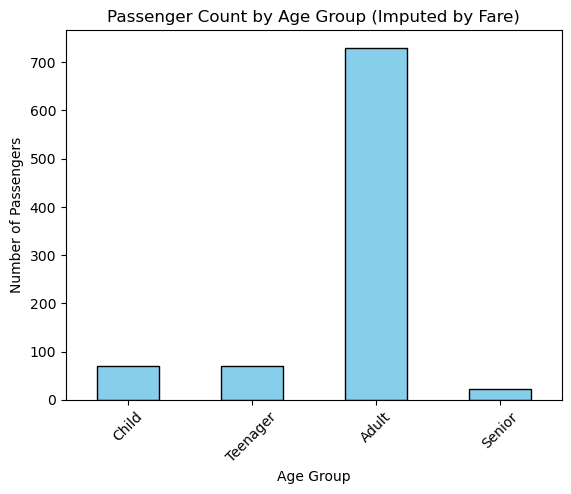

In [9]:
import matplotlib.pyplot as plt

# Count the values and plot
df_titanic['AgeGroup'].value_counts().reindex(labels).plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Passenger Count by Age Group (Imputed by Fare)')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=45)
plt.show()

# TO CHECK WITH AI if this "Fare-based filling" changed the Standard Deviation of the Age compared to before we filled it?

#### Displaying the graph for the '891 passengers' dataset

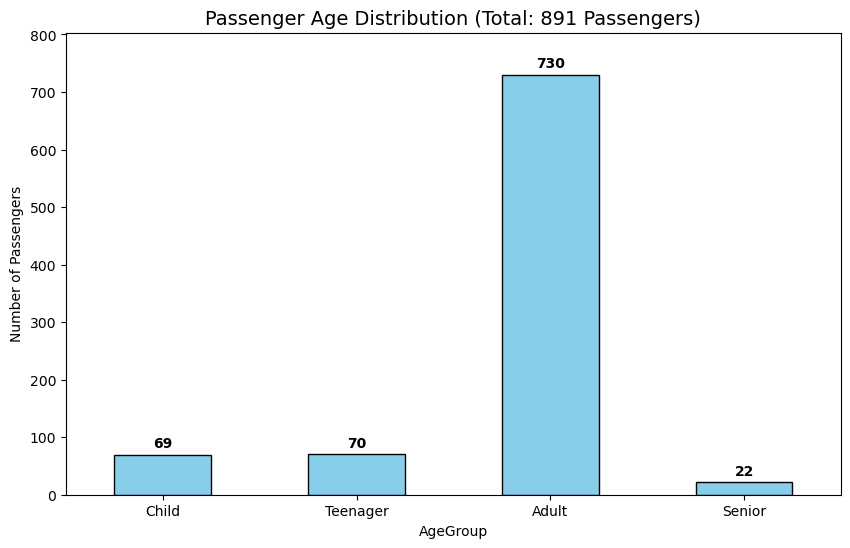

In [18]:
# Check the total count - should be 891
counts = df_titanic['AgeGroup'].value_counts().reindex(labels)
total = counts.sum()

ax = counts.plot(kind='bar', color='skyblue', edgecolor='black', figsize=(10, 6))

# Add the labels
ax.bar_label(ax.containers[0], padding=3, fontweight='bold')

# Add the total to the title so your colleagues know it's the full data
plt.title(f'Passenger Age Distribution (Total: {total} Passengers)', fontsize=14)
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.ylim(0, counts.max() * 1.1) # Multiplying the maximum count by 1.1 (adding 10% extra space) ensures there is always room for the text.

plt.savefig('Titanic_Age_Distribution.png', dpi=120, bbox_inches='tight')

plt.show()

In [ ]:
# Applying full-scale analysis 'Standard' Sections of Data Analysis to Titanic Data:

# (01) LOADING: df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\data.csv', encoding='cp1252')
# (02) INSPECTING: df.info(); df.describe(); df.columns/NEGLIGIBLE; 
# (03) CLEANING: Dropping, filling in for missing data and removing duplicates (wherever necessary)
# (04) SUMMERISING: Deciding what the data visualisation includes
# (05) VISUALISING: Graphs decision: bar, scatter etc...
# (06) EXPORTING: df.to_csv('/Users/micha/OneDrive/Desktop/data_exported.csv', index=False)
    # Exporting the graph: plt.savefig('/Users/micha/OneDrive/Desktop/Titanic_Age_Distribution.png', dpi=300, bbox_inches='tight')

In [22]:
# Caculating std & mean (using the 'Titanic Data'):
mean_age = df_titanic['Age'].mean()
std_fare = df_titanic['Fare'].std()

print(f"Mean Age: {mean_age:.2f} years")
print(f"Std of Fare: {std_fare:.2f}")

Mean Age: 29.70 years
Std of Fare: 49.69$


In [25]:
iris_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
# This file doesn't have headers, so we add them
cols = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Name']
df_iris = pd.read_csv(iris_url, names=cols)

print(f"Average Petal Length: {df_iris['PetalLength'].mean():.2f} cm")


# Exporting Data:
df = df_iris
df.to_csv('/Users/micha/OneDrive/Desktop/iris data.csv', index=False)
print('iris data exported')


Average Petal Length: 3.76 cm
iris data exported


In [26]:
# Reloading iris data from desktop:
df = pd.read_csv('C:\\Users\\micha\\OneDrive\\Desktop\\iris data.csv', encoding='cp1252')
df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# Create 100 RANDOM ages between 20 and 80
data = {'Age': np.random.randint(20, 80, size=100)}
practice_df = pd.DataFrame(data)
print(practice_df)

# Now practice your stats!
#print(f"Mean: {practice_df['Age'].mean():.2f}")
#print(f"Std Dev: {practice_df['Age'].std():.2f}")

    Age
0    66
1    39
2    33
3    23
4    72
..  ...
95   71
96   68
97   37
98   52
99   36

[100 rows x 1 columns]
Mean: 49.11
Std Dev: 16.75


### PRACTICING (01)

In [35]:
# Age passed in Function:
def years_tolive(age): 
    if age <= 0: # Checking if the argument is acceptable
        print("Age cannot be 0 or negative")
    else:
        try: # Where the calculation of the function occurs
            x = 100 - age
            print(f"Years to live: {x}")
        
        except Exception as e: # Is triggered when the code crashes; e.g. dividing by 0
            print(f"An unexpeted error occured: {e}")
          
years_tolive(10)

Years to live: 90


In [37]:
# Age is captured via an input prompt:
def years_tolive(age):
    if age <= 0: # Assessing the validity of the argument
        print("Error: Age must be a positive number.")
    elif age > 100:
        print("Congratulations! You've already hit the century mark!")
    else:
        # The core calculation
        x = 100 - age
        print(f"Based on a 100-year target, you have {x} years to live.")

# --- MAIN PROGRAM ---
try:
    # 1. Capture the age via an input prompt as an integer
    age = int(input("Enter your age: "))
    
    # 2. Pass that captured age into your function
    years_tolive(age)

except ValueError:
    # This catches if someone types "abc" instead of "25"
    print("Invalid input! Please enter a whole number (e.g., 25).")
    

Enter your age:  56


Based on a 100-year target, you have 44 years to live.


### Combining all codes into a single script

In [109]:
# .exe or executable distribution Structure Summary:

# (01) Creating the function: def run_analysis
# (02) 'try:' to contain all codes/steps when initially run manually
# (03) except Exception as e: for possible errors
# (04) if __name__ == "__main__": to call the function, here as run_analysis()


Initializing Titanic Analysis...
Creating Graph...
Success! Report saved as Titanic_Report.png


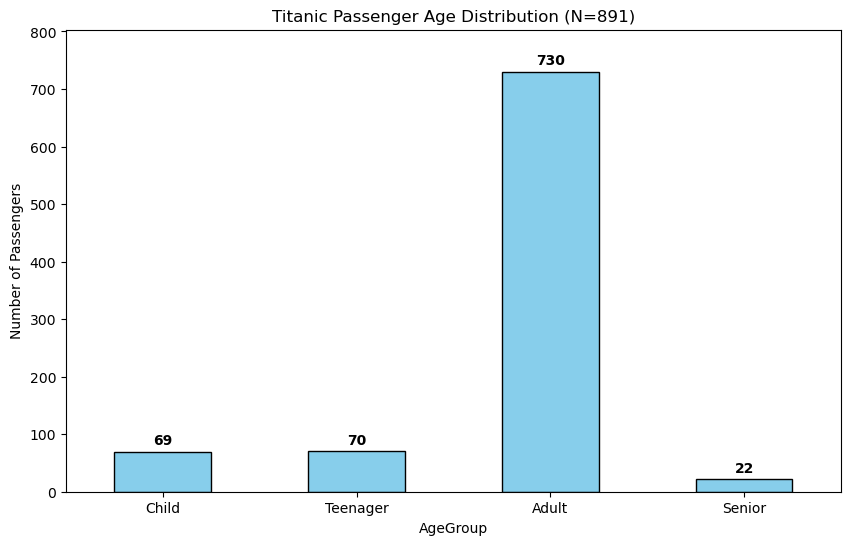


Press Enter to close this window... 


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def run_analysis():
    print("Initializing Titanic Analysis...")
    
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    
    try:
        # 1. Load
        df = pd.read_csv(url)
        
        # 2. Smart Fill (Crucial: This must happen first!)
        median_fare = df['Fare'].median()
        mean_age_rich = df[df['Fare'] > median_fare]['Age'].mean()
        mean_age_budget = df[df['Fare'] <= median_fare]['Age'].mean()

        df.loc[(df['Age'].isnull()) & (df['Fare'] > median_fare), 'Age'] = mean_age_rich
        df.loc[(df['Age'].isnull()) & (df['Fare'] <= median_fare), 'Age'] = mean_age_budget
        
        # 3. Categorize (This creates the 'AgeGroup' column)
        bins = [0, 12, 18, 60, 100]
        labels = ['Child', 'Teenager', 'Adult', 'Senior']
        df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
        
        # 4. Visualization
        print("Creating Graph...")
        counts = df['AgeGroup'].value_counts().reindex(labels)
        
        plt.figure(figsize=(10, 6))
        ax = counts.plot(kind='bar', color='skyblue', edgecolor='black')
        ax.bar_label(ax.containers[0], padding=3, fontweight='bold')
        
        plt.title(f'Titanic Passenger Age Distribution (N={len(df)})')
        plt.ylabel('Number of Passengers')
        plt.xticks(rotation=0)
        plt.ylim(0, counts.max() * 1.1)
        
        # 5. Export and Show
        plt.savefig('Titanic_Report.png', dpi=120, bbox_inches='tight')
        print("Success! Report saved as Titanic_Report.png")
        plt.show()

    except Exception as e:
        # This catches the 'AgeGroup' error and tells us exactly where it failed
        print(f"\n[ERROR]: The program failed at the following step: {e}")
    
    input("\nPress Enter to close this window...")

if __name__ == "__main__":
    run_analysis()

### PRACTICING (02)

In [74]:
clinic_data = pd.DataFrame({"Patient_ID": [101,102,103,104,101,106],
                "Visit_Date": ["Monday, 1st January 2026, 2:13 PM", "Tuesday, 12th February 2026, 10:11 AM", 
                               "Friday, 8th April 2026, 09:18 AM", "Sunday, 4th March 2026, 08:12 AM",
                              "Monday, 1st January 2026, 2:13 PM", "None"],
                "Blood_Pressure": [120, 145, "Error", 110, 120, 150],
                "Category": ["General", "General", "Follow-up", "General", "General", "First Visit"]})
clinic_data

# "Visit_Date": ["1st Jan 2026", "12th Feb 2026", "NaN", "4th Mar 2026"]

,Patient_ID,Visit_Date,Blood_Pressure,Category
0,101,"Monday, 1st January 2026, 2:13 PM",120,General
1,102,"Tuesday, 12th February 2026, 10:11 AM",145,General
2,103,"Friday, 8th April 2026, 09:18 AM",Error,Follow-up
3,104,"Sunday, 4th March 2026, 08:12 AM",110,General
4,101,"Monday, 1st January 2026, 2:13 PM",120,General
5,106,None,150,First Visit


In [75]:
# ********** Data Cleaning - Removing DUPLICATES *****************
df = clinic_data

# A. REMOVE DUPLICATES for Patient_ID
# 'subset' tells it which column to look at.
# 'keep=first' keeps the first instance and deletes any subsequent duplicates.
df = df.drop_duplicates(subset=['Patient_ID'], keep='first')
df

,Patient_ID,Visit_Date,Blood_Pressure,Category
0,101,"Monday, 1st January 2026, 2:13 PM",120,General
1,102,"Tuesday, 12th February 2026, 10:11 AM",145,General
2,103,"Friday, 8th April 2026, 09:18 AM",Error,Follow-up
3,104,"Sunday, 4th March 2026, 08:12 AM",110,General
5,106,None,150,First Visit


In [77]:
# --- Date Conversion EXECUTION ---

def format_visit_date(date_str):
    # 1. Handle None, NaN, or empty strings/whitespace
    if pd.isna(date_str) or str(date_str).strip().lower() in ['none', '']:
        return ""  # Returns a blank cell instead of crashing

    # 2. Ensure it's a string for regex processing
    date_str = str(date_str)

    # 3. Remove ordinal suffixes (st, nd, rd, th in "4th Mar 2026")
    clean_date = re.sub(r'(\d+)(st|nd|rd|th)', r'\1', date_str)
    
    try:
        # 4. Convert and format
        dt = pd.to_datetime(clean_date)
        return dt.strftime('%d/%m/%Y')
    except:
        # 5. Fallback in case there's a different weird text format
        return date_str 

# Example usage (to apply to column):
df = clinic_data
df['Visit_Date'] = df['Visit_Date'].apply(format_visit_date)
df


,Patient_ID,Visit_Date,Blood_Pressure,Category
0,101,01/01/2026,120,General
1,102,12/02/2026,145,General
2,103,08/04/2026,Error,Follow-up
3,104,04/03/2026,110,General
4,101,01/01/2026,120,General
5,106,,150,First Visit


In [78]:
# --- Blood_Pressure Filter EXECUTION ---

# Load your file (Change to .read_excel if using Excel)
df = clinic_data

# 2. CLEAN BLOOD PRESSURE
# errors='coerce' turns "None" or "Unknown" into NaN so we can filter safely
df['Blood_Pressure'] = pd.to_numeric(df['Blood_Pressure'], errors='coerce')

# 3. FILTER BY BLOOD PRESSURE
# This automatically removes rows where Blood_Pressure is NaN (None)
filtered_df = df[df['Blood_Pressure'] > 140].copy()

# 4. FORMAT THE DATE
filtered_df['Visit_Date'] = filtered_df['Visit_Date'].apply(format_visit_date)
filtered_df

# Save the result
# filtered_df.to_csv('filtered_patients.csv', index=False)

,Patient_ID,Visit_Date,Blood_Pressure,Category
1,102,02/12/2026,145.0,General
5,106,,150.0,First Visit


### WEEKLY GOAL

In [ ]:
# ***************************************************************************************************
#Load a CSV, clean it, summarise it, and visualise it end to end using pandas, NumPy, and matplotlib.
# ***************************************************************************************************

In [ ]:
# Tasks to serve for Weekly Goal:
# Leavers report (Removing duplicates, dropping columns, export as csv)
# Different_ID report (Removing duplicates, etc..)
# Training Data (medic or clin for data visualisation by Staff Groups or Division)
# Suspended Users (Date conversion)
# Training data (any course - Number of Quiz attempts) 
### To occasionally check the learnt topics in 'Panda's & 'CodeCamp_Python' for task-based Practice

In [79]:
pip install mysql-connector-python pandas scikit-learn


   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/16.5 MB 13.3 MB/s eta 0:00:02
   ------------ --------------------------- 5.2/16.5 MB 13.6 MB/s eta 0:00:01
   ------------------- -------------------- 8.1/16.5 MB 13.5 MB/s eta 0:00:01
   -------------------------- ------------- 11.0/16.5 MB 13.5 MB/s eta 0:00:01
   --------------------------------- ------ 13.6/16.5 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------  16.5/16.5 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 16.5/16.5 MB 12.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import mysql.connector
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. CONNECT TO YOUR MySQL DATABASE
# Replace these with your actual local credentials
db_config = {
    'host': 'localhost',
    'user': 'root',
    'password': 'your_password',
    'database': 'name_db'
}

try:
    conn = mysql.connector.connect(**db_config)
    query = "SELECT User_ID, Column_One, Age, Weight FROM Users"
    df = pd.read_sql(query, conn)
    conn.close()
    print("Successfully pulled data from MySQL!")
except Exception as e:
    print(f"Connection failed: {e}")

# 2. FEATURE CREATION (The logic we discussed)
# Let's create a 'Target'—what we want the AI to learn.
# For example: 1 = High Risk (BP > 140), 0 = Normal
df['High_Risk'] = (df['Column_name'] > 140).astype(int)

# 3. PREPARE DATA FOR THE MACHINE
# X = the 'Input' (Age, Weight), y = the 'Target' (High_Risk)
X = df[['Age', 'Weight']]
y = df['High_Risk']

# Split into Training data (80%) and Testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 4. CHOOSE AND TRAIN THE MODEL
# We'll use a Random Forest (very robust for medical data)
model = RandomForestClassifier()
model.fit(X_train, y_train)

# 5. MAKE A PREDICTION
# Let's predict a new patient: Age 55, Weight 90kg
new_patient = [[55, 90]]
prediction = model.predict(new_patient)

status = "High Risk" if prediction[0] == 1 else "Normal"
print(f"Prediction for new user: {status}")

In [ ]:
# Saving and Loading the Model (The "Pickle" Method)

import joblib

# 1. SAVE the model after you've trained it
# This creates a file named 'my_trained_model.pkl' in your folder
joblib.dump(model, 'my_trained_model.pkl')
print("Model saved to disk.")

# --- LATER, IN A DIFFERENT SCRIPT ---

# 2. LOAD the model back into memory
# You don't need the original data or the training code anymore
loaded_model = joblib.load('my_trained_model.pkl')

# 3. USE it to predict on new data
# Example: Predicting based on two generic features/variables
new_data_point = [[55, 90]] 
result = loaded_model.predict(new_data_point)
print(f"The model's prediction is: {result}")

In [31]:
iris_df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\iris_data.csv', encoding='cp1252')
iris_df.head()

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
X = iris_df.drop(columns=["Species"]) # Isolating features ($X$) by dropping the target
X.head()
print(iris_df.shape)
y = iris_df["Species"] # Isolating the target ($y$) into its own vector.

(150, 5)


In [24]:
print(X.shape)

(150, 4)


In [33]:
# Next Stage in Machine Learning:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [34]:
X_train.shape

(120, 4)

In [35]:
X_test.shape

(30, 4)

In [36]:
from sklearn.model_selection import train_test_split

# Perform the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# Check the 'Balance' of your Test Set
print("Flower counts in your Test Set:")
print(y_test.value_counts())

Flower counts in your Test Set:
Species
Iris-virginica     11
Iris-versicolor    10
Iris-setosa         9
Name: count, dtype: int64


In [88]:
import pandas as pd 

#df = pd.read_csv('titanic_data.csv')
#df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\titanic_data.csv', encoding='cp1252')
#df.head()

In [83]:
#female_travellers = df[df['Sex'] == 'female']
#female_travellers

In [75]:
#print(df.mean(numeric_only=True))
#print(df.max(numeric_only=True))
#print(df.min(numeric_only=True))
#print(df.sum(numeric_only=True)) # N/A
#print(df.count())

In [49]:
# df.info()

In [76]:
#print(df['Fare'].mean())
#print(df['Fare'].max())
#print(df['Fare'].min())
#print(df['Fare'].sum()) # N/A
#print(df['Fare'].count())

In [77]:
# Using grouby With Agg Funcions:
#group = df.groupby('Sex')
#print(group['Fare'].mean())
#print(group['Fare'].sum())
#print(group['Fare'].max())
#print(group['Fare'].min())
#print(group['Fare'].count())

#### The Use of loc & iloc

In [104]:
import pandas as pd 
#df = pd.read_csv('titanic_data.csv')
df = pd.read_csv(r'C:\Users\micha\OneDrive\Desktop\titanic_data.csv', encoding='cp1252')
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.55,NaN,S
1,747,0,3,"Abbott, Mr. Rossmore Edward",male,16.0,1,1,C.A. 2673,20.25,NaN,S
2,280,1,3,"Abbott, Mrs. Stanton (Rosa Hunt)",female,35.0,1,1,C.A. 2673,20.25,NaN,S
3,309,0,2,"Abelson, Mr. Samuel",male,30.0,1,0,P/PP 3381,24.00,NaN,C
4,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.00,NaN,C


In [112]:
# Syntax ...
# for loc - df.loc[row, column_name]
# for iloc - df.iloc[row, column_number]

#df.loc[:, 'Gender']
#df.loc[:, ['Gender', 'Ticket', 'Fare']]
#df.loc[:, 'Gender':'Fare']

#df.iloc[:, [3, 4]]
df.iloc[:, 3:6] # i.e. 3, 4 & 5

,Name,Gender,Age
0,"Abbing, Mr. Anthony",male,42.0
1,"Abbott, Mr. Rossmore Edward",male,16.0
2,"Abbott, Mrs. Stanton (Rosa Hunt)",female,35.0
3,"Abelson, Mr. Samuel",male,30.0
4,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0
...,...,...,...
886,"Yousseff, Mr. Gerious",male,NaN
887,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0
888,"Zabour, Miss. Hileni",female,14.5
889,"Zabour, Miss. Thamine",female,NaN
